# Теория вероятностей и математическая статистика

### ANOVA и парная линейная регрессия

*Алла Тамбовцева*

Импортируем необходимые библиотеки, модули и функции:

* библиотеку `pandas` для обработки данных;
* модуль `stats` из библиотеки `scipy` для статистических тестов;
* модуль `api` из библиотеки `statsmodels` для запуска статистических функций;
* функцию `ols()` для оценки линейной модели.

In [1]:
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import ols

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


Загрузим данные по ценам на квартиры в Москве (выгрузка с ЦИАН на апрель 2025 года):

In [2]:
flats = pd.read_csv("https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/flats_cian.csv")
print(flats.shape)

(103110, 11)


In [3]:
flats.head()

,price,lprice,square,rooms,floor,mfloor,station,metro,ametro,dmetro,link
0,13281237,16.401863,54.3,2,2,9,метро Аннино,4 минуты пешком,1,4,https://www.cian.ru/sale/flat/316370232/
1,16000000,16.588099,53.2,2,15,17,метро Аннино,9 минут пешком,1,9,https://www.cian.ru/sale/flat/316762421/
2,36508182,17.413047,104.1,4,3,30,метро Аннино,4 минуты пешком,1,4,https://www.cian.ru/sale/flat/307195712/
3,12000000,16.300417,60.0,3,1,9,метро Аннино,6 минут на транспорте,0,6,https://www.cian.ru/sale/flat/314948168/
4,11500000,16.257858,50.4,2,2,17,метро Аннино,10 минут пешком,1,10,https://www.cian.ru/sale/flat/316513485/


Переменные в файле:

* `price`: цена квартиры (в рублях);
* `lprice`: цена квартиры (натуральный логарифм);
* `square`: площадь квартиры (в квадратных метрах);
* `rooms`: число комнат;
* `floor`: этаж;
* `mfloor`: общее число этажей в доме;
* `station`: станция метро;
* `metro`: доступность метро;
* `ametro`: доступность метро (1 – шаговая доступность, можно дойти пешком, 0 – иначе);
* `dmetro`: расстояние до метро (в минутах, пешком или на транспорте);
* `link`: ссылка на предложение на сайте.

### Часть 1: описание и подготовка данных

a. Выведите описательные статистики для цены и площади квартир (`price` и `square`). Постройте гистограмму для цены квартир. Что можно сказать о распределении?

b. Постройте гистограмму и ящик с усами для натурального логарифма цены квартиры (`lprice`). Удалите нехарактерные значения.

c. Добавьте в датафрейм столбец `ftype`, классифицирующий этажи, на которых находятся квартиры:

* `"first"` – первый,
* `"last"` – последний,
* `"other"` – остальные.

### Решения

a. Выведем описательные статистики для цены и площади квартиры:

In [4]:
# выбираем два столбца из датафрейма и выводим по ним описание
print(flats[["price", "square"]].describe())

              price         square
count  1.031100e+05  103110.000000
mean   4.452741e+07      70.221368
std    9.641154e+07      44.607468
min    1.690000e+06       8.300000
25%    1.285000e+07      42.500000
50%    1.946846e+07      58.000000
75%    3.800000e+07      79.700000
max    2.862950e+09     979.500000


Кажется, что максимальное значение цены и площади неправдоподобны, однако можем убедиться, перейдя по ссылке, что такое предложение на ЦИАН есть, и там, действительно, дорогие огромные 5-комнатные апартаменты в Центральном административном округе (они еще и в ипотеку их предлагают):

In [5]:
# отфильтровываем квартиры с max ценой, выбираем столбец link со ссылкой
flats[flats["price"] == flats["price"].max()]["link"]

55598    https://www.cian.ru/sale/flat/316200743/
72905    https://www.cian.ru/sale/flat/316200743/
72941    https://www.cian.ru/sale/flat/316200743/
Name: link, dtype: object

В данных есть дубликаты – по сути это одна и та же квартира (две строки – точные дубликаты, ещё одна – формально объявление другое, так как указана другая станция метро, но квартира та же):

In [6]:
flats[flats["price"] == flats["price"].max()]

,price,lprice,square,rooms,floor,mfloor,station,metro,ametro,dmetro,link
55598,2862950000,21.775118,979.5,5,1,3,метро Полянка,2 минуты на транспорте,0,2,https://www.cian.ru/sale/flat/316200743/
72905,2862950000,21.775118,979.5,5,1,3,метро Боровицкая,20 минут пешком,1,20,https://www.cian.ru/sale/flat/316200743/
72941,2862950000,21.775118,979.5,5,1,3,метро Боровицкая,20 минут пешком,1,20,https://www.cian.ru/sale/flat/316200743/


Как можно заметить, распределение цены квартиры `price` скошено вправо (среднее сильно больше медианы, большой разрыв между верхнем квартилем и максимумом), плюс, размах значений тоже большой. Убедимся в этом, построив гистограмму:

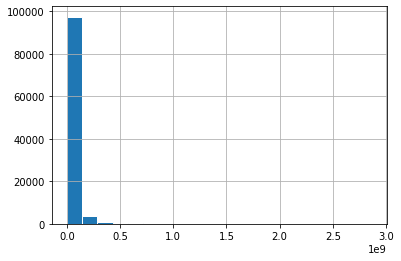

In [7]:
# гистограмма с 20 столбцами, цвет границ столбцов – белый
flats["price"].hist(edgecolor = "white", bins = 20);

b. Чтобы немного снизить скошенность распределения, в таких случаях интересующий показатель обычно логарифмируют, поэтому дальше мы будем работать с натуральным логарифмом цены квартиры `lprice`:

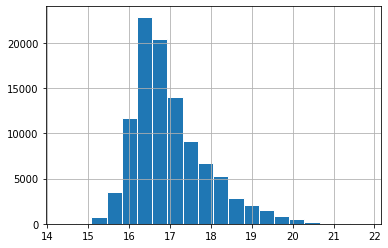

In [8]:
# white можно сократить до w
flats["lprice"].hist(edgecolor = "w", bins = 20);

Распределение этого показателя тоже скошено, но уже не так радикально, плюс, разброс значений за счет логарифмирования снизился. Проверим наличие нехарактерных значений (выбросов), построив ящик с усами:

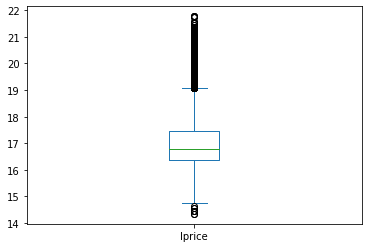

In [9]:
flats["lprice"].plot.box();

Выбросов много, давайте от них избавимся, оставив только квартиры с характерными значениями цены. 

> По-хорошему, так как в третьей части нам потребуется модель, описывающая зависимость цены квартиры от ее площади, квартиры с нехарактерными значениями площади тоже стоит убрать. Но мы их оставим. Во-первых, очень нетипичные по площади квартиры уберутся автоматически при удалении квартир с запредельно высокой ценой. Во-вторых, хочется посмотрить на модель, для которой не будут выполняться условия Гаусса-Маркова.

In [10]:
# вычисляем квартили, межквартильный размах 
# и границы типичных значений для логарифма цены

Q1, Q3 = flats["lprice"].quantile([0.25, 0.75])
Delta = Q3 - Q1
Lower = Q1 - 1.5 * Delta
Upper = Q3 + 1.5 * Delta

# фильтруем наблюдения – оставляем только те, что между
# Lower и Upper включительно, метод .between()

flats = flats[flats["lprice"].between(Lower, Upper)]
print(flats.shape) # было 103110 квартир до удаления

(99250, 11)


c. Добавим столбец `ftype` – пригодится для части 2. В датафрейме `flats` есть два столбца: `floor` (этаж) и `mfloor` (число этажей в доме).  Представим себе работу с парами вида `(floor, mfloor)`, тогда нам нужно:

* проверить равенство `floor` значению 1 – если выполняется, вернуть `"first"`;
* проверить равенство `floor` значению `mfloor` – если выполняется, вернуть `"last"`;
* иначе вернуть `"other"`.

Напишем функцию для подобной пары, а потом применим ее построчно к столбцам в `flats`.

In [11]:
# предполагаем, что пропусков нет,
# иначе нужно дополнительное условие, 
# чтобы на пропуск возвращался пропуск

def get_type(floor, mfloor):
    if floor == 1:
        res = "first"
    elif floor == mfloor:
        res = "last"
    else:
        res = "other"
    return res

# выбираем пару нужных столбцов,
# применяем через apply() написанную функцию построчно

flats["ftype"] = flats[["floor", "mfloor"]].apply(lambda row: get_type(row["floor"], 
                                                      row["mfloor"]), axis = 1)
# выводим таблицу частот – проверяем, что 
# значения получились разнообразные

flats["ftype"].value_counts()

other    83092
last      9734
first     6424
Name: ftype, dtype: int64

**Дополнительно – комментарий к коду.** Метод `.apply()` умеет применять функцию ко всем элементам столбца/столбцов сразу. Например, код ниже вернет столбец из `True` и `False`, где `True` соответствует этажам, кратным 5 или 2:

In [12]:
# x – одна ячейка в столбце floor,
# пишем lambda-функцию и «растягиваем» ее на столбец

flats["floor"].apply(lambda x: (x % 5 == 0) | (x % 2 == 0))

0          True
1          True
2         False
3         False
4          True
          ...  
103105     True
103106     True
103107    False
103108    False
103109    False
Name: floor, Length: 99250, dtype: bool

Однако иногда возникает необходимость применить функцию не к одному столбцу, а сразу к нескольким, причем применить построчно. Ровно как в нашей задаче. Представьте себе цикл по строкам таблицы:

|    |   floor |   mfloor |
|---:|--------:|---------:|
|  0 |       2 |        9 |
|  1 |      15 |       17 |
|  2 |       3 |       30 |
|  3 |       1 |        9 |
|  4 |       2 |       17 |

На первой итерации цикла сравниваем 2 и 9, на второй – 15 и 17, и так далее. Чтобы не писать долгий цикл, можем написать функцию, которая работает со строкой вида 

|    |   floor |   mfloor |
|---:|--------:|---------:|
|  0 |       2 |        9 |

Функция принимает на вход строку (например, `row`), выбирает в ней значение из столбцов `floor` и `mfloor`, сравнивает их через нашу функцию `get_type()` и возвращает единственный результат. Это мы и описываем строкой 

    flats[["floor", "mfloor"]].apply(lambda row: get_type(row["floor"], 
                                                      row["mfloor"]), axis = 1)
                                                      
Метод `.apply()` «растягивает» lambda-функцию на все строки столбцов `floor`, `mfloor`, применяя ее к каждой строке благодаря аргументу `axis = 1` (по умолчанию `axis = 0`, применение к каждому столбцу).

### Часть 2: ANOVA

Модель ANOVA эквивалентна линейной регрессионной модели, где зависимая переменная – количественная (интересующий нас признак), а независимая – качественная (название группы). Поэтому в некоторых языках программирования или их библиотеках для получения привычной ANOVA-таблицы нужно оценить соответствующую линейную модель.

Представьте, что нам нужно проверить гипотезу о равенстве средней цены квартир (в логарифмированном виде) в трёх группах – в зависимости от типа этажа (первый, последний, другой):

$$
H_0: a_1 = a_2 = a_3
$$
$$
H_1: \exists i,j \quad a_i \ne a_j
$$

Напишите в кавычках ниже формулу вида `y ~ x`, где вместо `y` и `x` указаны подходящие переменные. Запустите код и проинтерпретируйте полученные результаты.

In [13]:
m_aov = ols("lprice ~ ftype", data = flats).fit()
print(sm.stats.anova_lm(m_aov))

               df        sum_sq     mean_sq           F  PR(>F)
ftype         2.0   1046.701186  523.350593  911.868948     0.0
Residual  99247.0  56961.010000    0.573932         NaN     NaN


### Решения

Итак, мы получили классическую ANOVA-таблицу для $k=3$ групп (число наблюдений $n=99250$). Здесь `ftype` – это строка для суммы квадратов, объясненных моделью (Model SS или Explained SS), а `Residual` – строка для суммы квадратов остатков (Residual SS). Отсюда:

* MSS = ESS = $\text{SS}_{between}$ = 1046.70 (межгрупповая дисперсия)
* RSS = $\text{SS}_{within}$ = 56961.01 (внутригрупповая дисперсия, сумма по всем группам сразу)

В столбце `df` указаны числа степеней свободы. Для MSS это $\text{df} = k - 1 = 2$, для RSS это $\text{df} = n - k = 99247$. Если разделим суммы квадратов на соответствующие числа степеней свободы, получим средние суммы квадратов, указанные в `mean_sq`:

* Mean MSS = Mean ESS = 1046.70/2 = 523.35
* Mean RSS = 56961.01/99247 = 0.57

Чтобы понять, во сколько раз межгрупповая дисперсия превышает внутригрупповую (если во много раз, разница в средних объясняется делением на группы, а значит, гипотеза о равенстве средних отвергается), и проделать это с учетом числа групп и числа наблюдений, нужно Mean MSS разделить на Mean RSS. В итоге получим наблюдаемое значение статистики F-критерия, который всегда возникает при сравнении дисперсий:

$$
F_{набл} = 523.35 / 0.57 = 911.87
$$

Это значение принадлежит распределению $F(\text{df}_1 = 2, \text{df}_2 = 99247)$. Для такого распределения считаем вероятность $\text{P}(F > 911.87)$, получаем p-value равное 0, в таблице это `PR(>F)`.

**Итого:** на любом конвенциональном уровне значимости (1%, 5%, 10%) нулевая гипотеза отвергается, значит, существует как минимум одна пара групп, где средние цены квартир отличаются. 

Чтобы более подробно изучить различия между отдельными группами, можно, например, запросить описание линейной модели через `m_aov.summary()`. Об этом можно будет почитать в дополнительных материалах – к ним логично обращаться после знакомства с выдачей более привычной линейной регрессии, где и зависимая, и независимая переменная числовые.

P.S. Значения `NaN` в таблице ожидаемы, это не следствия ошибки или пропусков в данных. В логике ANOVA мы делим Mean MSS на Mean RSS, а не наоборот. Поэтому для обратного отношения F-значение не определено, и p-value, соответственно, тоже.

In [14]:
# к слову, на сами средние и дисперсии перед ANOVA 
# тоже неплохо бы посмотреть

flats.groupby("ftype")["lprice"].agg(["mean", "var"])

,mean,var
ftype,,
first,16.509569,0.441258
last,16.888180,0.666487
other,16.928356,0.573346


### Часть 3: парная линейная регрессия

Построим линейную модель, которая предсказывает цену квартиры (в логарифмированном виде) в зависимости от её площади:

In [15]:
mod01 = ols("lprice ~ square", data = flats).fit()
print(mod01.summary())

                            OLS Regression Results                            
Dep. Variable:                 lprice   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                 1.306e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:59:52   Log-Likelihood:                -72509.
No. Observations:               99250   AIC:                         1.450e+05
Df Residuals:                   99248   BIC:                         1.450e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.7653      0.004   4484.924      0.0

a. Запишите уравнение модели. Проинтерпретируйте полученные результаты.

b. Добавьте в датафрейм `flats` столбец `yhat` с предсказанными значениями цены квартир (атрибут `.fittedvalues`) и столбец `resid` с остатками модели (атрибут `.resid`). Используя полученные столбцы, проверьте, можно ли считать, что для данной модели выполняются условия Гаусса-Маркова. Поскольку формальные критерии для проверки не обсуждались, предполагается анализ графиков и описательных статистик.



### Решения

a. Сфокусируемся на второй части, это основная выдача для модели. В столбце `coef` указаны коэффициенты модели $\hat{b}_0$ и $\hat{b}_1$, это константа `Intercept` и угол наклона, коэффициент при `square`. Запишем уравнение модели:

$$
\widehat{lprice}_i = 15.77 + 0.017 \times square_i
$$

Получается, при увеличении площади квартиры на один квадратный метр логарифм ее цены, в среднем, увеличивается на 0.017. Константа в данном случае не интерпретируема, по определению это среднее ожидаемое значение цены, когда площадь квартиры равна 0. Таких квартир не бывает (теоретически, константа вообще могла оказаться отрицательной). 

Интерпретировать коэффициенты в модели, где только одна переменная логарифмирована, не очень удобно, в данном случае, не совсем ясно, на сколько изменяется сама цена квартиры, если ее логарифм увеличивается. Возьмем экспоненту от коэффициента 0.017:

In [16]:
import math
print(math.exp(0.017))

1.0171453223252407


Можем заключить, что при увеличении площади квартиры на 1 квадратный метр, ее цена, в среднем, увеличивается в 1.017 раза, то есть, на 1.7%. Чтобы сразу получить изменения в процентах, можно было бы рассмотреть модель, где и зависимая, и независимая переменная логарифмированы, но не будем переключаться на такие модели, почитать про интерпретацию моделей с логарифмами переменных можно [здесь](https://library.virginia.edu/data/articles/interpreting-log-transformations-in-a-linear-model).

Во втором столбце `std err` сохранены значения стандартных ошибок коэффициентов $SE(\hat{b}_0)$ и $SE(\hat{b}_1)$, которые показывают, как, в среднем, значения оценок коэффициентов могут отличаться при запуске модели на разных выборках такого же размера. Как вычисляются эти ошибки, будем обсуждать позже, когда посмотрим на ANOVA-таблицу, поэтому пока больше в этой части выдачи ничего трогать не будем.

b. Добавим столбцы с предсказанными значениями цены ($\hat{y} = \widehat{\text{lprice}}$) и остатками ($\hat{\varepsilon}$).

In [17]:
flats["yhat"] = mod01.fittedvalues
flats["resid"] = mod01.resid

In [18]:
# кстати, можем убедиться, что остатки 
# resid = y - yhat, 
# то есть lprice - lprice^

flats[["lprice", "yhat", "resid"]].head()

,lprice,yhat,resid
0,16.401863,16.708911,-0.307048
1,16.588099,16.689796,-0.101697
2,17.413047,17.574282,-0.161235
3,16.300417,16.807959,-0.507542
4,16.257858,16.641141,-0.383283


### Немного об остатках модели

Оценки коэффициентов, полученные с помощью метода наименьших квадратов, можно считать надежными, если выполняется условия Гаусса-Маркова:

* $\varepsilon_i$ – случайная величина, поведение ошибок модели случайно, они не подчиняются какой-то закономерности.
* $E(\varepsilon_i) = 0$, среднее ожидаемое значение ошибок модели равно 0, то есть модель может ошибаться в предсказании значения $y$ для $i$-того наблюдения как в большую, так и в меньшую сторону, но в теории, если мы будем повторять аналогичные исследования независимым образом много-много раз, средняя ошибка для этого наблюдения будет нулевой.
* $\varepsilon_i$, $\varepsilon_j$ независимы для любых наблюдений $i$ и $j$, то есть то, что модель ошибается в предсказании значения $y$ для одного наблюдения, никак не сказывается на ошибке предсказания для другого наблюдения. Нарушение этого условия называется *автокорреляцией*.
* $D(\varepsilon_i) = \sigma^2$, дисперсия ошибок постоянна и не зависит от значений независимой переменной, то есть модель ошибается примерно одинаково как при маленьких значениях независимой переменной, так и при больших. Это условие называется *гомоскедастичностью*, а его нарушение – *гетероскедастичностью*.
* $\varepsilon_i$ и $x_i$ независимы, это условие называется *экзогенностью*, а его нарушение – *эндогенностью*.

Также дополнительно выделяют условие $\varepsilon_i \sim N(0, \sigma^2)$, остатки модели имеют нормальное распределение со средним, равным нулю, и некоторой дисперсией. Оно не относится к условиям Гаусса-Маркова, но часто идет в связке с ними (условия Гаусса-Маркова+). При выполнении условий Гаусса-Маркова оценки коэффициентов линейной регрессии, полученные с помощью метода метода наименьших квадратов, считаются лучшими в классе линейных несмещенных оценок (*BLUE – best linear unbiased estimators*), а если в добавок выполняется условие нормальности остатков, то они считаются лучшими в классе несмещенных оценок вообще, не только линейных (*BUE – best unbiased estimators*).

Не все из условий выше обязательно проверяются; некоторые из них обеспечиваются по построению (равенство математического ожидания остатков нулю). Тем не менее, посмотрим, на распределение остатков модели:

count    99250.000
mean        -0.000
std          0.502
min         -5.733
25%         -0.299
50%         -0.049
75%          0.284
max          2.137
Name: resid, dtype: float64


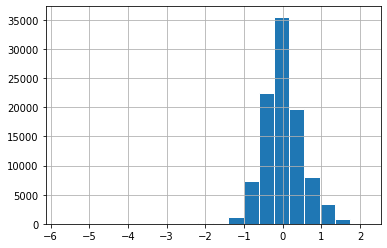

In [19]:
print(flats["resid"].describe().round(3))
flats["resid"].hist(bins = 20, edgecolor = "w");

В целом, можно считать, что распределение остатков довольно симметрично (среднее близко к медиане), однако, судя по границам значений в гистограмме (от -6 до 2) и по минимальному значению -5.733, в распределении остатков явно есть нехарактерно маленькие значения. Формально проверять нормальность распределения остатков не будем (и нормальность остатков – это, скорее, дополнение к условиям Гаусса-Маркова), обратим внимание на то, что у распределения довольно острый пик, у «идеально» нормального распределения такого нет. Посмотрим на последнюю часть основной выдачи регрессии выше:

```
==============================================================================
Omnibus:                     4551.269   Durbin-Watson:                   0.825
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13607.244
Skew:                           0.183   Prob(JB):                         0.00
Kurtosis:                       4.777   Cond. No.                         161.
==============================================================================
```

* `Skew` – коэффициент скошенности распределения, у симметричных распределений он равен 0. 
* `Kurtosis` – эксцесс, показатель остроты пика распределения. Для стандартного нормального распределения этот показатель равен 3, здесь коэффициент более 3, что свидетельствует об остром пике распределения (можете построить график плотности с высокой детализацией при сглаживании и увидеть его более ярко).

*Примечание.* В центрированном виде `Kurtosis` для стандартного нормального распределения равен 0, но здесь не центрированный вариант. Если вычислить коэффицент через `stats.kurtosis(flats["resid"])`, получим центрированный коэффициент эксцесса равный 1.777, как раз на 3 меньше. В общем, в таких случаях нужно всегда читать документацию перед тем, как сравнивать результаты с какими-то референтными значениями :) 

Проверим «на глаз» выполнение еще некоторых условий – построим диаграмму рассеивания между независимой переменной и остатками:

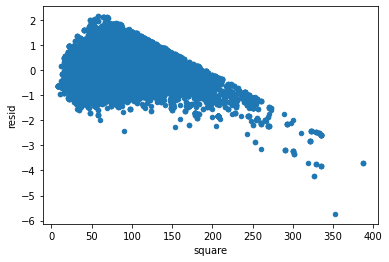

In [20]:
flats.plot.scatter(x = "square", y = "resid");

Для надежных выводов требуется, чтобы дисперсия остатков была постоянной, $D(\varepsilon_i) = \sigma^2$, то есть, не изменялась сильно при увеличении независимой переменной. Здесь это не выполняется, разброс точек относительно прямой $\text{residuals} = 0$ совсем не одинаков при разных значениях `square`. Это означает, что модель неодинаково ошибается при предсказании цен на квартиры как маленькой, так и большой площади. И для качества модели это плохо. Если бы это условие не выполняется, мы всегда увидим на диаграмме рассеивания сходящуюся (дисперсия ошибок снижается при увеличении `square`) или расходящуюся (дисперсия ошибок увеличивается при увеличении `square`) «воронку» из точек.

Остальные условия трогать не будем, там более сложная история (и не всегда формальным тестам и p-value можно верить), небольшой спойлер для желающих – во фрагменте выдачи выше:

* `Durbin-Watson` – p-value для критерия Дарбина-Уотсона с гипотезой об отсутствии связи между остатками (автокорреляции); 
* `Jarque-Bera` и `Prob(JB)` – значение статистики и p-value для критерия Харке — Бера с гипотезой о нормальности распределения остатков.

### Бонус

Уберем все-таки квартиры с нетипичными значениями площади – оставим в `flats` только типичные:

In [21]:
q1, q3 = flats["square"].quantile([0.25, 0.75])
delta = q3 - q1
lower = q1 - 1.5 * delta
upper = q3 + 1.5 * delta
flats = flats[flats["square"].between(lower, upper)]
print(flats.shape) # было 99250 квартир до удаления

(93451, 14)


Переоценим модель и посмотрим на графики остатков:

In [22]:
mod02 = ols("lprice ~ square", data = flats).fit()
print(mod02.summary())

                            OLS Regression Results                            
Dep. Variable:                 lprice   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                 1.033e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:59:52   Log-Likelihood:                -62734.
No. Observations:               93451   AIC:                         1.255e+05
Df Residuals:                   93449   BIC:                         1.255e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.4904      0.004   3533.861      0.0

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


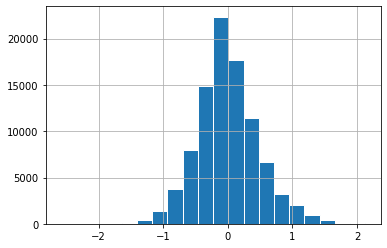

In [23]:
flats["yhat2"] = mod02.fittedvalues
flats["resid2"] = mod02.resid

flats["resid2"].hist(bins = 20, edgecolor = "w");

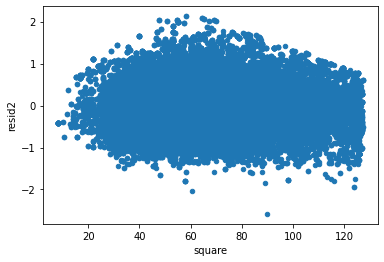

In [24]:
flats.plot.scatter(x = "square", y = "resid2");

Стало лучше! Во-первых, в распределении остатков уже нет явных выбросов. Во-вторых, исчезла проблема гетероскедастичности. На диаграмме рассеивания облако точек везде примерно одинаковой ширины (вокруг прямой $\text{residuals} = 0$), модель ошибается примерно одинаково в предсказании цены квартир как маленькой, так и большой площади. Постоянство дисперсии остатков выполняется, тут даже формальных тестов не потребуется.